In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array

train_dir = r'train'
test_dir = r'test'

In [2]:
# Steg 1 Förstå datan
classes = os.listdir(train_dir)
print('Klasser: ')
print(classes)

print('\nAntal träningsbilder per klass: ')
for emtion in classes:
    folder = os.path.join(train_dir, emtion)
    print(emtion, ':', len(os.listdir(folder)))

print('\nAntal testbilder per klass: ')
for emotion in os.listdir(test_dir):
    folder = os.path.join(test_dir, emotion)
    print(emotion, ":", len(os.listdir(folder)))

Klasser: 
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Antal träningsbilder per klass: 
angry : 3995
disgust : 436
fear : 4097
happy : 7215
neutral : 4965
sad : 4830
surprise : 3171

Antal testbilder per klass: 
angry : 958
disgust : 111
fear : 1024
happy : 1774
neutral : 1233
sad : 1247
surprise : 831


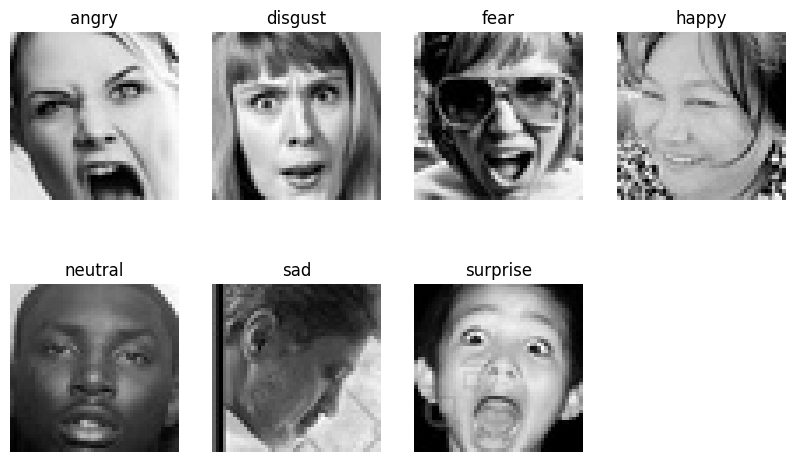

In [3]:
# Visa upp några bilder
plt.figure(figsize=(10,6))

for i, emotion in enumerate(classes[:7]):
    folder = os.path.join(train_dir, emotion)
    image_name = random.choice(os.listdir(folder))
    image_path = os.path.join(folder, image_name)
    img = load_img(image_path, color_mode='grayscale')

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(emotion)
    plt.axis('off')
plt.tight_layout
plt.show()


# Jag visualiserade exempelbilder från varje klass för att få en bättre förståelse för datan

In [4]:
# Steg 2 Förbered datan
img_size = (48, 48)
batch_size = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=123
)

val_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=123
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size
)

# Sparar klassnamnen

class_names = train_data.class_names
print(class_names)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [5]:
# Normaliserar bilderna från 0 - 255 till 0 - 1
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))
test_data = test_data.map(lambda x, y: (normalization_layer(x), y))

In [6]:
# För en snabbare träning
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)
test_data = test_data.cache().prefetch(buffer_size=AUTOTUNE)

In [7]:
# Steg 3 Bygg en modell
model = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

In [8]:
# Visar CNN modellen
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Jag valde en CNN eftersom convolutional layers är bra på att hitta mönster i bilder, till exempel kanter, former och delar av ansikten. MaxPooling används för att minska bildens storlek stegvis och göra modellen mer effektiv. Dropout används för att minska risken för overfitting.

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Jag använder Adam som optimizer eftersom den ofta fungerar bra som standardval. Eftersom det finns flera klasser använder jag sparse categorical crossentropy som loss function. Accuracy används som metric för att se hur stor andel bilder modellen klassificerar rätt.

In [10]:
# Steg 4 Träna modellen
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.3052 - loss: 1.7269 - val_accuracy: 0.4041 - val_loss: 1.5773
Epoch 2/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4073 - loss: 1.5268 - val_accuracy: 0.4614 - val_loss: 1.4153
Epoch 3/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4572 - loss: 1.4108 - val_accuracy: 0.4870 - val_loss: 1.3374
Epoch 4/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4866 - loss: 1.3463 - val_accuracy: 0.5102 - val_loss: 1.2986
Epoch 5/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5061 - loss: 1.2938 - val_accuracy: 0.5072 - val_loss: 1.2854


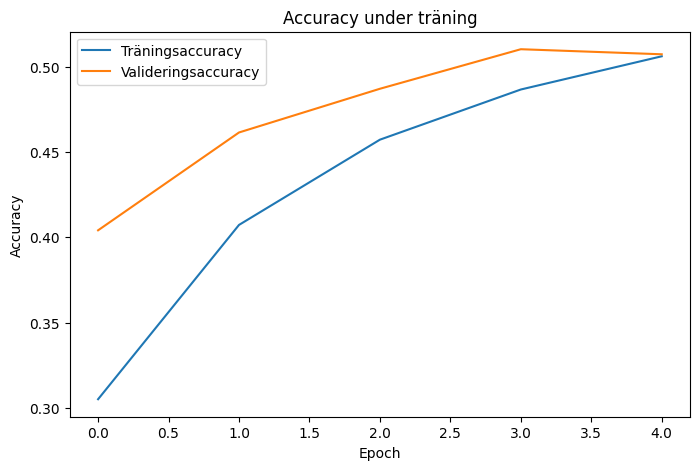

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Träningsaccuracy')
plt.plot(history.history['val_accuracy'], label='Valideringsaccuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy under träning')
plt.show()

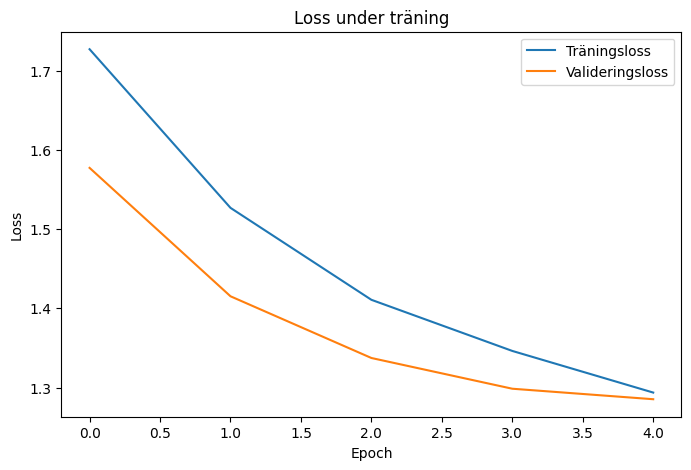

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Träningsloss')
plt.plot(history.history['val_loss'], label='Valideringsloss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss under träning')
plt.show()

Jag följde accuracy och loss under träningen för att se om modellen blev bättre över tid. Om träningsaccuracy ökar men valideringsaccuracy stannar av eller minskar kan det vara ett tecken på overfitting.

In [13]:
# Steg 5 Utvärdera modellen
test_loss, test_accuracy = model.evaluate(test_data)

print('Test loss:', test_loss)
print('Test accuracy:', test_accuracy)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5078 - loss: 1.2746
Test loss: 1.274623990058899
Test accuracy: 0.5078015923500061


Testdatan används först efter träningen för att se hur modellen fungerar på bilder den inte tränats på. Detta är viktigt eftersom modellen annars kan verka bättre än den egentligen är.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


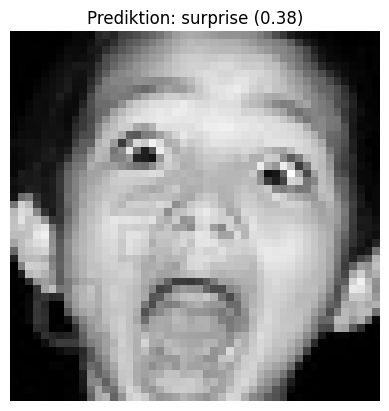

('surprise', np.float32(0.3812741))

In [14]:
def predict_image(image_path):
    img = load_img(image_path, color_mode='grayscale', target_size=(48, 48))
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    predicted_class = class_names[predicted_index]
    confidence = np.max(prediction)

    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f'Prediktion: {predicted_class} ({confidence:.2f})')
    plt.show()

    return predicted_class, confidence

predict_image(image_path)

Rätt klass: neutral
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


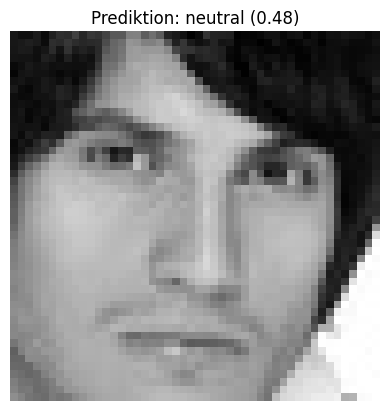

('neutral', np.float32(0.4808604))

In [15]:
# Radnom test bild
emotion = random.choice(class_names)
folder = os.path.join(test_dir, emotion)
image_name = random.choice(os.listdir(folder))
image_path = os.path.join(folder, image_name)

print('Rätt klass:', emotion)
predict_image(image_path)

In [16]:
model.save('emotion_cnn_model.h5')

Jag sparade modellen så att den kan användas igen utan att behöva tränas om från början.